Equality scale keq = 0.0104 h/Mpc


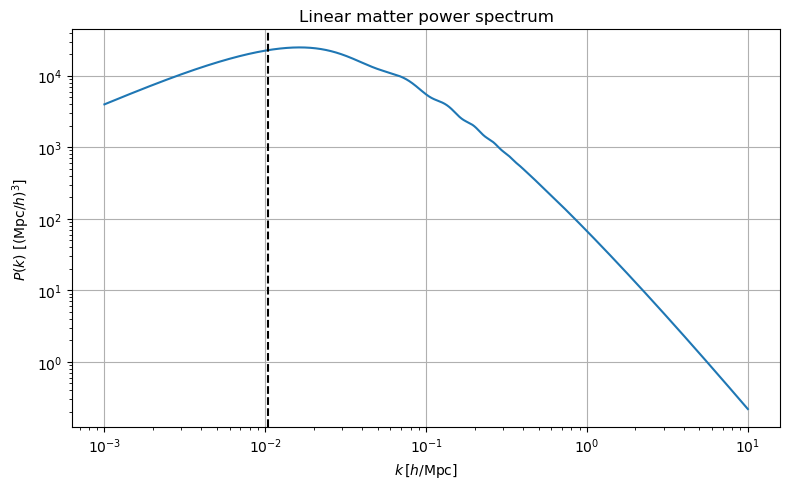

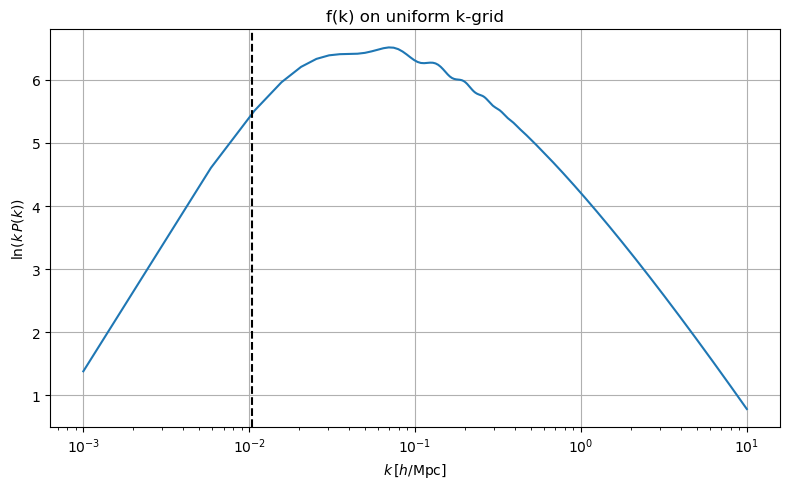


Thresholds (|d²f/dk²|, 50th percentile) in BAO range:
  Even spline: 10.9
  Odd spline:  11.3

Number of k points with both curvatures large: 76
k range: 0.04008 to 0.43574 h/Mpc
First 10 bad k values:
[0.04008, 0.04496, 0.04985, 0.05473, 0.05962, 0.0645 , 0.06939, 0.07427,
 0.07916, 0.08404]


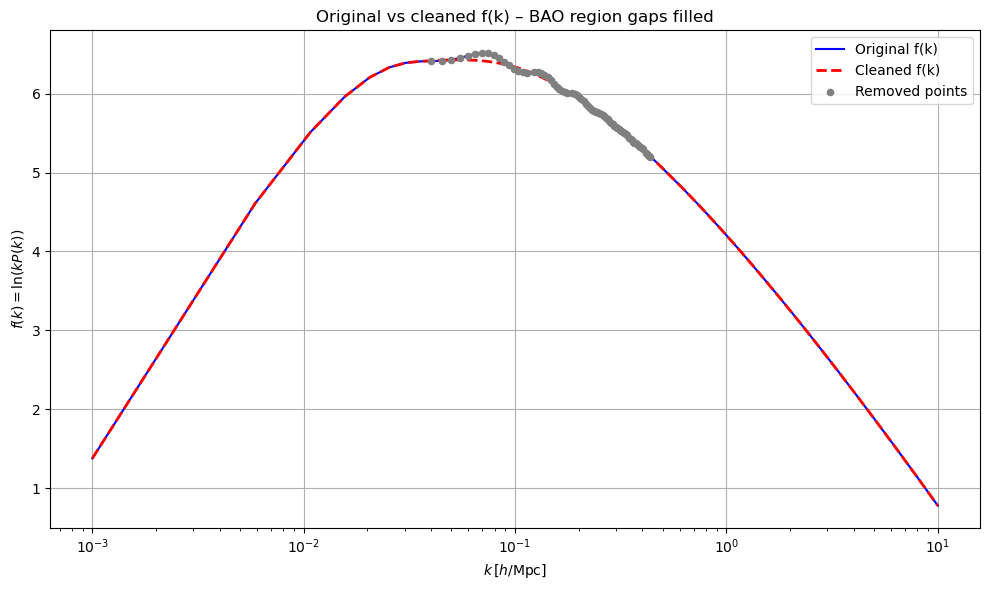

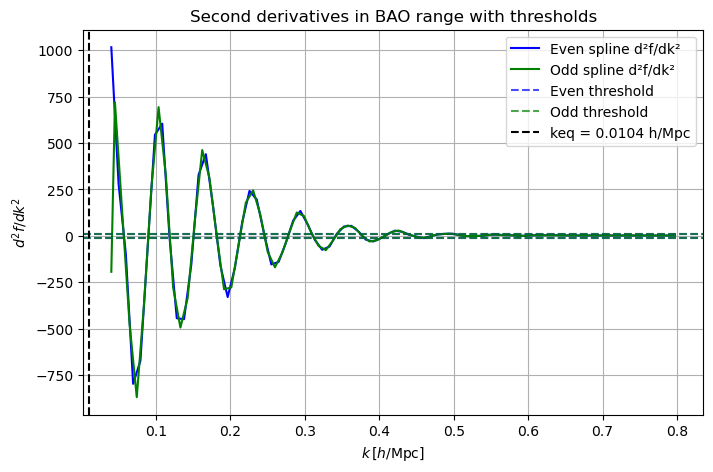

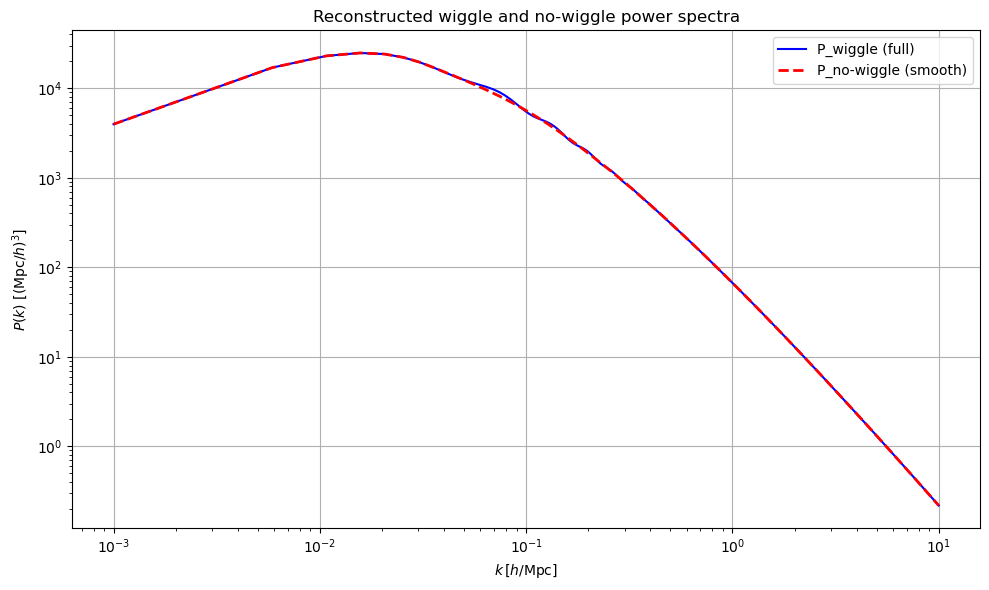

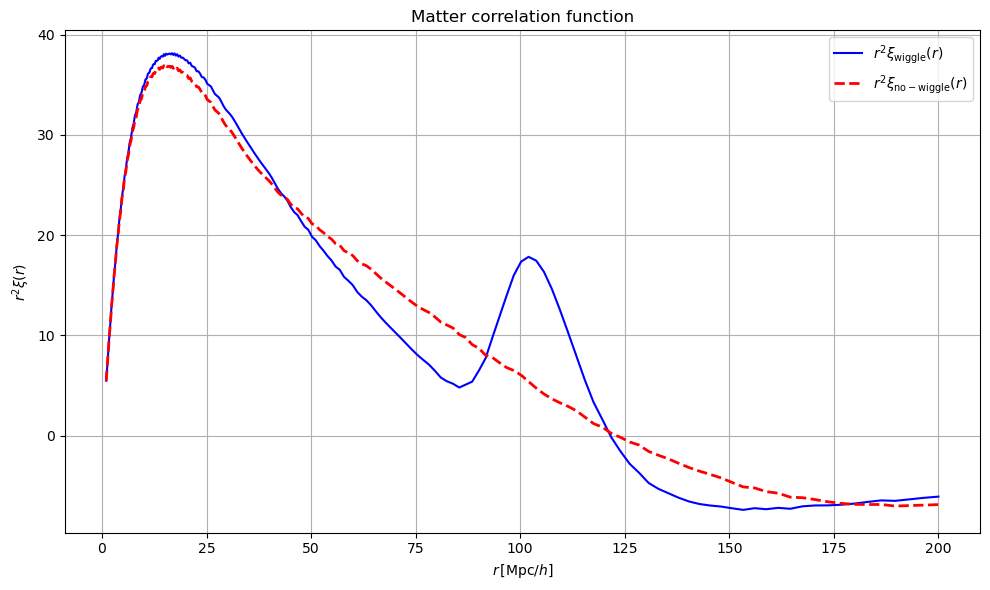

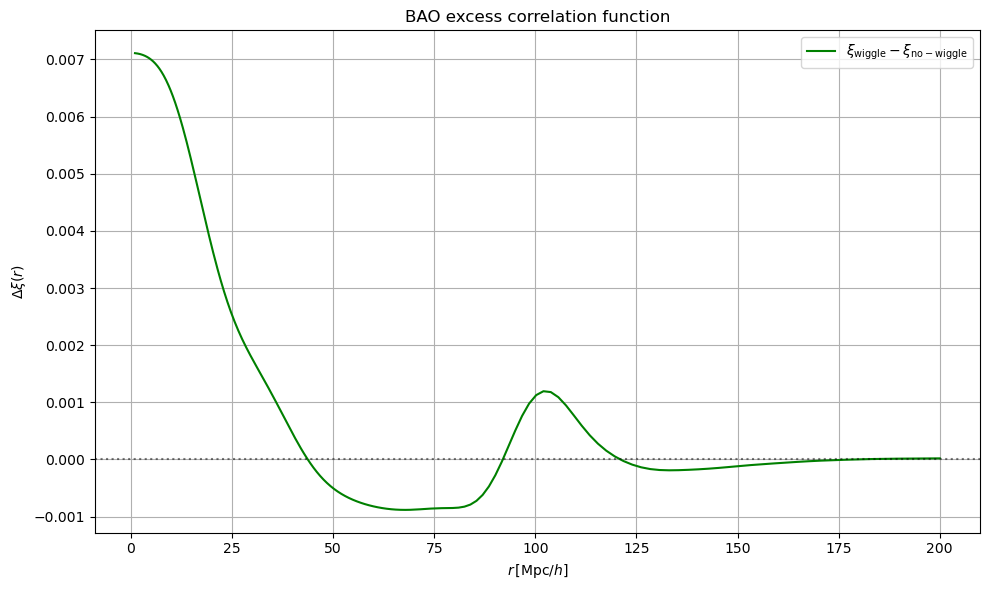

Done! Correlation functions computed.


In [5]:
import numpy as np
import camb
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline

# ==============================================================================
# 0. Free Parameters
# =============================================================================

# k range for BAO
k_min_BAO = 0.04
k_max_BAO = .8

# percentile for large curvature
percentile_d2 = 50

# number of points for uniform grid (N = 2^n)
n = 11

# ============================================================================
# 1. Compute linear matter power spectrum with CAMB
# ============================================================================

# Cosmological parameters
H0 = 67.7                 # km/s/Mpc
omega_b = 0.022           # baryon density * h^2
omega_cdm = 0.12          # cold dark matter density * h^2
ns = 0.96                 # scalar spectral index
As = 2.1e-9               # primordial amplitude

# Set up CAMB
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=omega_b, omch2=omega_cdm)
pars.InitPower.set_params(As=As, ns=ns)

# k range in h/Mpc (native CAMB units)
k_min_hMpc = 1e-3
k_max_hMpc = 10.0
pars.set_matter_power(redshifts=[0], kmax=k_max_hMpc)

# Compute power spectrum
results = camb.get_results(pars)
keq = results.get_derived_params()['keq']
print(f"Equality scale keq = {keq:.4f} h/Mpc")
kh, z, pk = results.get_matter_power_spectrum(minkh=k_min_hMpc, maxkh=k_max_hMpc, npoints=10000)
Plin = pk[0]                       # units: (Mpc/h)^3

# Plot linear power spectrum
plt.figure(figsize=(8,5))
plt.loglog(kh, Plin)
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \ [(\mathrm{Mpc}/h)^3]$')
plt.axvline(keq, color='k', linestyle='--', label=f'keq = {keq:.4f} h/Mpc')
plt.title("Linear matter power spectrum")
plt.grid()
plt.tight_layout()
plt.show()

# ============================================================================
# 2. Uniform k grid and interpolation of f(k) = ln(k P(k))
# ============================================================================

N = 2**n                                     
k_uniform = np.linspace(k_min_hMpc, k_max_hMpc, N)

# Linear interpolation of ln(k*P) in linear k space
interp_lnkP = interp1d(kh, np.log(kh * Plin), kind='linear',
                       fill_value='extrapolate')
lnkP_uniform = interp_lnkP(k_uniform)
f = lnkP_uniform                             # f(k) = ln(k * P(k))

# Plot f(k) on the uniform grid
plt.figure(figsize=(8,5))
plt.plot(k_uniform, f)
plt.axvline(keq, color='k', linestyle='--', label=f'keq = {keq:.4f} h/Mpc')
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$\ln(k\,P(k))$')
plt.xscale('log')
plt.title('f(k) on uniform k-grid')
plt.grid()
plt.tight_layout()
plt.show()

# ============================================================================
# 3. Split data into even and odd indices
# ============================================================================

even_mask = (np.arange(N) % 2 == 0)
odd_mask  = ~even_mask

k_even = k_uniform[even_mask]
f_even = f[even_mask]

k_odd  = k_uniform[odd_mask]
f_odd  = f[odd_mask]

# ============================================================================
# 4. Cubic splines for even and odd subsets
# ============================================================================

# 'natural' boundary conditions (zero second derivative at ends)
spline_even = CubicSpline(k_even, f_even, bc_type='natural')
spline_odd  = CubicSpline(k_odd,  f_odd,  bc_type='natural')

# ============================================================================
# 5. Compute second derivatives on the uniform k grid
# ============================================================================

d2_even_uniform = spline_even.derivative(2)(k_uniform)
d2_odd_uniform  = spline_odd.derivative(2)(k_uniform)

# ============================================================================
# 6. Determine large curvature thresholds within BAO k-range
# ============================================================================

bao_mask = (k_uniform >= k_min_BAO) & (k_uniform <= k_max_BAO)

abs_d2_even_bao = np.abs(d2_even_uniform[bao_mask])
abs_d2_odd_bao  = np.abs(d2_odd_uniform[bao_mask])

thresh_even = np.percentile(abs_d2_even_bao, percentile_d2)
thresh_odd  = np.percentile(abs_d2_odd_bao, percentile_d2)

print(f"\nThresholds (|d²f/dk²|, {percentile_d2}th percentile) in BAO range:")
print(f"  Even spline: {thresh_even:.3g}")
print(f"  Odd spline:  {thresh_odd:.3g}")

# ============================================================================
# 7. Find k where BOTH even and odd splines have large curvature (within BAO)
# ============================================================================

both_large = (bao_mask) & \
             (np.abs(d2_even_uniform) > thresh_even) & \
             (np.abs(d2_odd_uniform) > thresh_odd)

k_bad = k_uniform[both_large]

print(f"\nNumber of k points with both curvatures large: {len(k_bad)}")
if len(k_bad) > 0:
    print(f"k range: {k_bad.min():.5f} to {k_bad.max():.5f} h/Mpc")
    print("First 10 bad k values:")
    print(np.array2string(k_bad[:10], precision=5, separator=', '))

# ============================================================================
# 8. Remove bad points (only inside BAO) and fill gaps with cubic spline
# ============================================================================

good_mask = ~both_large
k_good = k_uniform[good_mask]
f_good = f[good_mask]

spline_clean = CubicSpline(k_good, f_good, bc_type='natural')

# Replace f(k) only inside BAO region with spline interpolation
f_clean = f.copy()
f_clean[bao_mask] = spline_clean(k_uniform[bao_mask])

# ============================================================================
# 9. Visualisation: original vs cleaned f(k)
# ============================================================================

plt.figure(figsize=(10,6))
plt.plot(k_uniform, f, 'b-', label='Original f(k)', linewidth=1.5)
plt.plot(k_uniform, f_clean, 'r--', label='Cleaned f(k)', linewidth=2)
if len(k_bad) > 0:
    plt.scatter(k_bad, f[both_large], color='gray', s=20, zorder=3, label='Removed points')
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$f(k) = \ln(k P(k))$')
plt.title('Original vs cleaned f(k) – BAO region gaps filled')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.tight_layout()
plt.show()

# ============================================================================
# 10. (Optional) Plot second derivatives before cleaning (only BAO range)
# ============================================================================

plt.figure(figsize=(8,5))
plt.plot(k_uniform[bao_mask], d2_even_uniform[bao_mask], 'b-', label='Even spline d²f/dk²')
plt.plot(k_uniform[bao_mask], d2_odd_uniform[bao_mask],  'g-', label='Odd spline d²f/dk²')
plt.axhline( thresh_even, color='b', linestyle='--', alpha=0.7, label='Even threshold')
plt.axhline(-thresh_even, color='b', linestyle='--', alpha=0.7)
plt.axhline( thresh_odd,  color='g', linestyle='--', alpha=0.7, label='Odd threshold')
plt.axhline(-thresh_odd,  color='g', linestyle='--', alpha=0.7)
plt.axvline(keq, color='k', linestyle='--', label=f'keq = {keq:.4f} h/Mpc')
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$d^2f/dk^2$')
plt.title('Second derivatives in BAO range with thresholds')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================================
# 11. Reconstruct P_wiggle(k) and P_no‑wiggle(k)
# ============================================================================

kP_wiggle = np.exp(f)          # = k * P_wiggle(k)
kP_nowiggle = np.exp(f_clean)  # = k * P_nowiggle(k)

P_wiggle = kP_wiggle / k_uniform
P_nowiggle = kP_nowiggle / k_uniform

plt.figure(figsize=(10,6))
plt.loglog(k_uniform, P_wiggle, 'b-', label='P_wiggle (full)', linewidth=1.5)
plt.loglog(k_uniform, P_nowiggle, 'r--', label='P_no‑wiggle (smooth)', linewidth=2)
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \ [(\mathrm{Mpc}/h)^3]$')
plt.title('Reconstructed wiggle and no‑wiggle power spectra')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================================
# 12. Compute correlation functions ξ(r) via Hankel transform
# ============================================================================

r_min = 1.0
r_max = 200.0
n_r = 300
r_array = np.logspace(np.log10(r_min), np.log10(r_max), n_r)

factor = 1.0 / (2.0 * np.pi**2)

xi_wiggle = np.zeros_like(r_array)
xi_nowiggle = np.zeros_like(r_array)

for i, r in enumerate(r_array):
    integrand_w = kP_wiggle * np.sin(k_uniform * r)
    integrand_nw = kP_nowiggle * np.sin(k_uniform * r)
    xi_wiggle[i] = (factor / r) * np.trapezoid(integrand_w, k_uniform)
    xi_nowiggle[i] = (factor / r) * np.trapezoid(integrand_nw, k_uniform)

# ============================================================================
# 13. Plot correlation functions
# ============================================================================

plt.figure(figsize=(10,6))
plt.plot(r_array, xi_wiggle * r_array**2, 'b-', label=r'$r^2\xi_{\mathrm{wiggle}}(r)$', linewidth=1.5)
plt.plot(r_array, xi_nowiggle * r_array**2, 'r--', label=r'$r^2\xi_{\mathrm{no-wiggle}}(r)$', linewidth=2)
plt.xlabel(r'$r \, [\mathrm{Mpc}/h]$')
plt.ylabel(r'$r^2\xi(r)$')
plt.title('Matter correlation function')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================================
# 14. Wiggle‑only component (BAO excess)
# ============================================================================

xi_BAO = xi_wiggle - xi_nowiggle

plt.figure(figsize=(10,6))
plt.plot(r_array, xi_BAO, 'g-', label=r'$\xi_{\mathrm{wiggle}} - \xi_{\mathrm{no-wiggle}}$')
plt.axhline(0, color='k', linestyle=':', alpha=0.5)
plt.xlabel(r'$r \, [\mathrm{Mpc}/h]$')
plt.ylabel(r'$\Delta \xi(r)$')
plt.title('BAO excess correlation function')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Done! Correlation functions computed.")